# Exploratory Data Analysis: Marketing A/B Test

**Dataset**: [Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing)  
**Goal**: Compare frequentist and Bayesian approaches to analyzing this A/B test, including how each handles sequential monitoring ("peeking").

**Groups**:
- `ad`: users shown the marketing ad (564,577 users)
- `psa`: control group shown a public service announcement instead (23,524 users)

**Initial observation**: The `ad` group converts at ~2.55%, vs. ~1.79% for the `psa` group — a meaningful-looking lift on a fairly low base rate, with a notably unbalanced sample size between groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/marketing_AB.csv')
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [2]:
df.shape

(588101, 7)

In [3]:
df.groupby('test group')['converted'].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [4]:
df['test group'].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [5]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [6]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


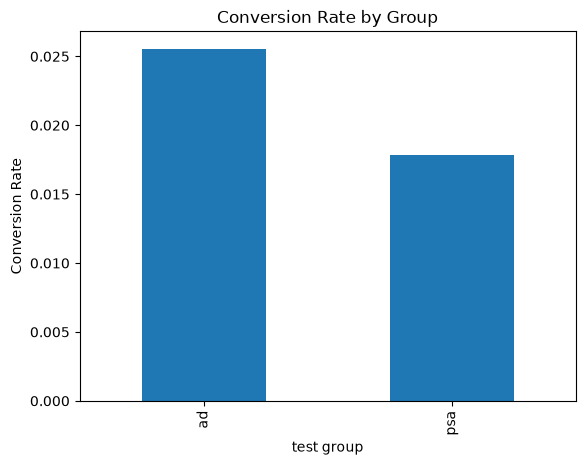

In [7]:
conversion_rates = df.groupby('test group')['converted'].mean()
conversion_rates.plot(kind='bar', title='Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.show()

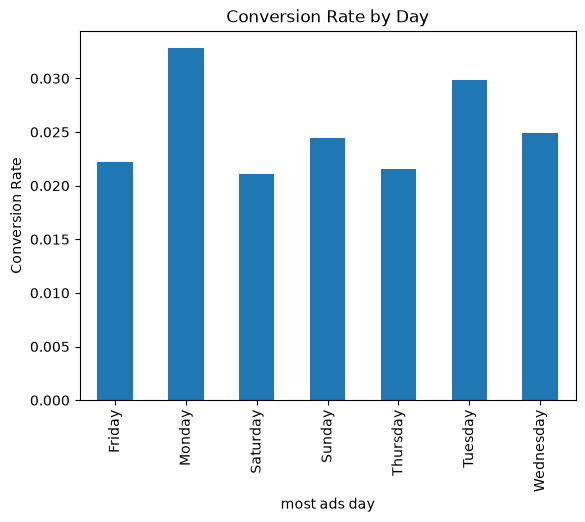

In [8]:
df.groupby('most ads day')['converted'].mean().plot(kind='bar', title='Conversion Rate by Day')
plt.ylabel('Conversion Rate')
plt.show()

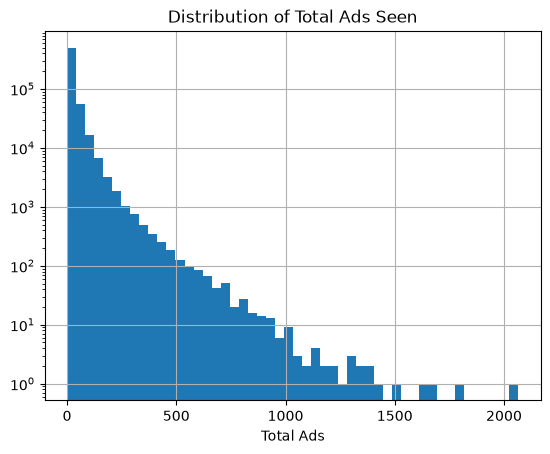

In [9]:
df['total ads'].hist(bins=50)
plt.yscale('log')
plt.title('Distribution of Total Ads Seen')
plt.xlabel('Total Ads')
plt.show()

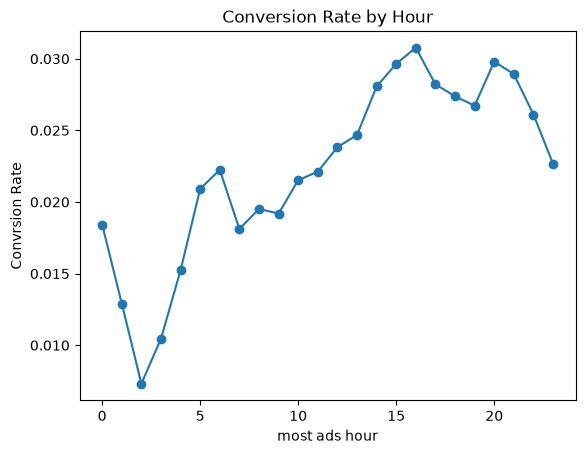

In [10]:
df.groupby('most ads hour')['converted'].mean().plot(kind='line', marker='o', title='Conversion Rate by Hour')
plt.ylabel('Convrsion Rate')
plt.show()

## Frequentist Analysis: Two-Proportion Z-Test

Testing whether the difference in conversion rates between `ad` and `psa` groups is statistically significant.

**H0**: conversion rate(ad) = conversion rate(psa)  
**H1**: conversion rate(ad) ≠ conversion rate(psa)

In [11]:
from statsmodels.stats.proportion import proportions_ztest

#Count of conversions and total observations per group
conversions = df.groupby('test group')['converted'].sum()
totals = df.groupby('test group')['converted'].count()

print(conversions)
print(totals)

test group
ad     14423
psa      420
Name: converted, dtype: int64
test group
ad     564577
psa     23524
Name: converted, dtype: int64


In [12]:
count = np.array([conversions['ad'], conversions['psa']])
nobs = np.array([totals['ad'], totals['psa']])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.10f}")

Z-statistic: 7.3701
P-value: 0.0000000000


In [13]:
from statsmodels.stats.proportion import proportion_confint

#Confidence intervals for each group's conversion rate
ci_ad = proportion_confint(conversions['ad'], totals['ad'], alpha=0.05)
ci_psa = proportion_confint(conversions['psa'], totals['psa'], alpha=0.05)

print(f"Ad group 95% CI: {ci_ad}")
print(f"PSA group 95% CI: {ci_psa}")

Ad group 95% CI: (0.0251349995427061, 0.025958119730661394)
PSA group 95% CI: (0.016161914715211324, 0.019546298173753137)


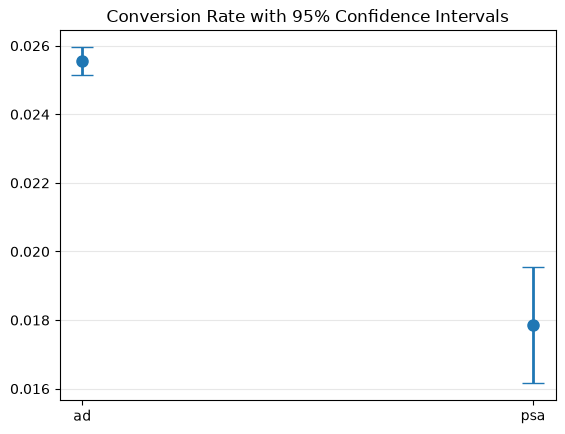

In [14]:
groups = ['ad', 'psa']
rates = [rate_ad if 'rate_ad' in dir() else conversions['ad']/totals['ad'],
        rate_psa if 'rate_psa' in dir() else conversions['psa']/totals['psa']]
ci_lower = [ci_ad[0], ci_psa[0]]
ci_upper = [ci_ad[1], ci_psa[1]]
errors = [[rates[i] - ci_lower[i] for i in range(2)], [ci_upper[i] - rates[i] for i in range(2)]]

plt.errorbar(groups, rates, yerr=errors, fmt='o', capsize=8, markersize=8, linewidth=2)
plt.title('Conversion Rate with 95% Confidence Intervals')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [15]:
rate_ad = conversions['ad'] / totals['ad']
rate_psa = conversions['psa'] / totals['psa']
relative_lift = (rate_ad - rate_psa) / rate_psa

print(f"Ad conversion rate: {rate_ad:.4f}")
print(f"PSA conversion rate: {rate_psa:.4f}")
print(f"Relative lift: {relative_lift:.2%}")

Ad conversion rate: 0.0255
PSA conversion rate: 0.0179
Relative lift: 43.09%


## Frequentist Summary

- Z-test result: z = 7.37, p < 0.0001 → statistically significant difference in conversion rates
- Ad group: 2.55% (95% CI: 2.51%–2.60%)
- PSA group: 1.79% (95% CI: 1.62%–1.95%)
- Relative lift: ~43% higher conversion rate for the ad group
- Confidence intervals do not overlap, reinforcing the significance finding
- Note: PSA group's wider interval reflects its much smaller sample size (23,524 vs 564,577)

## Bayesian Analysis: Beta-Binomial Model

Modeling each group's conversion rate as Beta-distributed. Starting with an uninformative (flat) prior: Beta(1,1), which assumes no prior knowledge about conversion rates.

**Posterior update rule**: Beta(α + successes, β + failures)

In [16]:
from scipy import stats

#Uninformative prior: Beta(1,1) = uniform distribution
alpha_prior, beta_prior = 1,1

# Posterior parameters for each group
alpha_ad = alpha_prior + conversions['ad']
beta_ad = beta_prior + (totals['ad'] - conversions['ad'])

alpha_psa = alpha_prior + conversions['psa']
beta_psa = beta_prior + (totals['psa'] - conversions['psa'])

print(f"Ad posterior: Beta({alpha_ad}, {beta_ad})")
print(f"PSA posterior: Beta({alpha_psa}, {beta_psa})")

Ad posterior: Beta(14424, 550155)
PSA posterior: Beta(421, 23105)


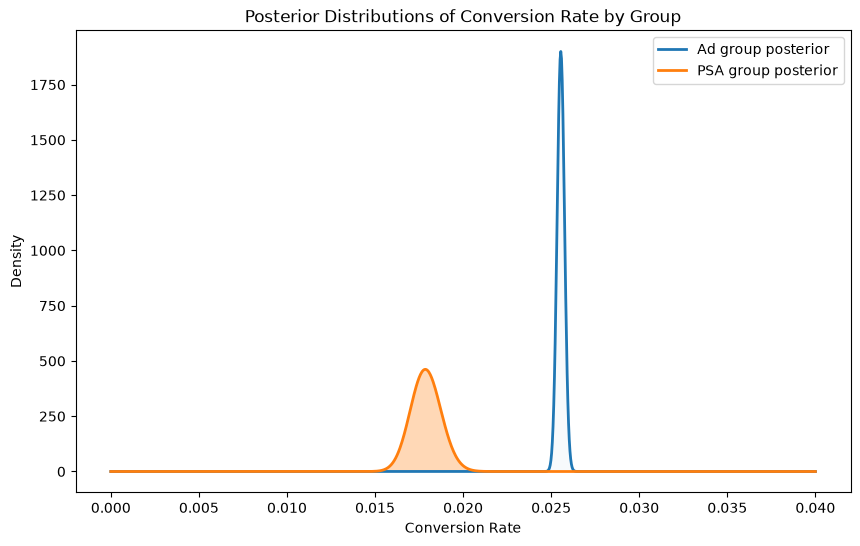

In [17]:
x = np.linspace(0, 0.04, 1000)

pdf_ad = stats.beta.pdf(x, alpha_ad, beta_ad)
pdf_psa = stats.beta.pdf(x, alpha_psa, beta_psa)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf_ad, label='Ad group posterior', linewidth=2)
plt.plot(x, pdf_psa, label='PSA group posterior', linewidth=2)
plt.fill_between(x, pdf_ad, alpha=0.03)
plt.fill_between(x, pdf_psa, alpha=0.3)
plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.title('Posterior Distributions of Conversion Rate by Group')
plt.legend()
plt.show()

In [18]:
# Monte Carlo estimate of P(ad > psa) using sampling from each posterior
np.random.seed(42)
samples_ad = stats.beta.rvs(alpha_ad, beta_ad, size=100000)
samples_psa = stats.beta.rvs(alpha_psa, beta_psa, size=100000)

prob_ad_better = (samples_ad > samples_psa).mean()
print(f"P(ad conversion rate > psa conversion rate): {prob_ad_better:.4f}")

# 95% credible intervals
ci_ad_bayes = stats.beta.ppf([0.025, 0.975], alpha_ad, beta_ad)
ci_psa_bayes = stats.beta.ppf([0.025, 0.975], alpha_psa, beta_psa)

print(f"Ad group 95% credible interval: {ci_ad_bayes}")
print(f"PSA group 95% credible interval: {ci_psa_bayes}")

P(ad conversion rate > psa conversion rate): 1.0000
Ad group 95% credible interval: [0.02513826 0.0259614 ]
PSA group 95% credible interval: [0.01624027 0.01962755]


### Prior Sensitivity Check

Testing whether the choice of prior meaningfully affects the posterior, given how much data we have. Using a skeptical prior — Beta(2, 200) — which assumes, before seeing data, that conversion rates are low (centered around 1%).

In [19]:
alpha_skeptical, beta_skeptical = 2, 200

alpha_ad_skeptical = alpha_skeptical + conversions['ad']
beta_ad_skeptical = beta_skeptical + (totals['ad'] - conversions['ad'])

alpha_psa_skeptical = alpha_skeptical + conversions['psa']
beta_psa_skeptical = beta_skeptical + (totals['psa'] - conversions['psa'])

#Compare posteriro means: flat prior vs. skeptical prior
print("Flat prior posteriro means:")
print(f" Ad: {alpha_ad / (alpha_ad + beta_ad):.5f}")
print(f" PSA: {alpha_psa / (alpha_psa + beta_psa):.5f}")

print("\nSkeptical prior posterior means:")
print(f" Ad: {alpha_ad_skeptical / (alpha_ad_skeptical + beta_ad_skeptical):.5f}")
print(f" PSA: {alpha_psa_skeptical / (alpha_psa_skeptical + beta_psa_skeptical):.5f}")

Flat prior posteriro means:
 Ad: 0.02555
 PSA: 0.01790

Skeptical prior posterior means:
 Ad: 0.02554
 PSA: 0.01779


### Prior Sensitivity: Conclusion

Even a fairly informative skeptical prior (Beta(2,200), centered near 1%) barely shifts the posterior mean for either group — a change of ~0.001 percentage points for the smaller PSA group, and negligible change for the larger Ad group. This confirms that with sample sizes this large, the data dominates the prior. Prior choice will matter more in the sequential/small-sample analysis in the next section.

## Comparing Frequentist and Bayesian Intervals

Visual comparison of the 95% confidence intervals (frequentist) and 95% credible intervals (Bayesian) for each group.

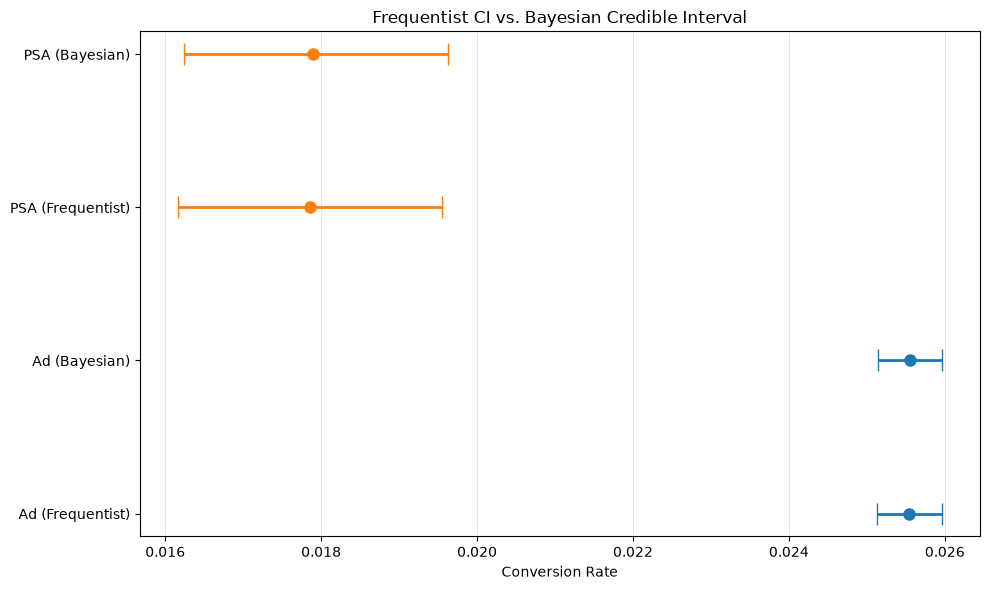

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ['Ad (Frequentist)', 'Ad (Bayesian)', 'PSA (Frequentist)', 'PSA (Bayesian)']
centers = [rate_ad, alpha_ad/(alpha_ad+beta_ad), rate_psa, alpha_psa/(alpha_psa+beta_psa)]
lowers = [ci_ad[0], ci_ad_bayes[0], ci_psa[0], ci_psa_bayes[0]]
uppers = [ci_ad[1], ci_ad_bayes[1], ci_psa[1], ci_psa_bayes[1]]
errors_lower = [centers[i] - lowers[i] for i in range(4)]
errors_upper = [uppers[i] - centers[i] for i in range(4)]
colors = ['tab:blue', 'tab:blue', 'tab:orange', 'tab:orange']

y_pos = np.arange(len(labels))

for i in range(4):
    ax.errorbar(centers[i], y_pos[i], xerr=[[errors_lower[i]], [errors_upper[i]]],
                fmt='o', capsize=8, markersize=8, linewidth=2, color=colors[i])

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Conversion Rate')
ax.set_title('Frequentist CI vs. Bayesian Credible Interval')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Bayesian vs. Frequentist: Summary

With a flat (uninformative) prior and large sample sizes, the Bayesian credible intervals and frequentist confidence intervals are nearly identical for both groups — confirming that with enough data, the choice of framework doesn't change the practical conclusion. The Bayesian approach additionally gives us **P(ad > psa) = 1.0000**, a directly interpretable probability statement that the frequentist framework cannot produce.

The real divergence between these two approaches will show up in the next section, where we simulate what happens with **much smaller samples and sequential monitoring ("peeking")** — a scenario where frequentist p-values become unreliable but Bayesian posteriors remain well-behaved.

## Sequential Monitoring: The "Peeking Problem"

Simulating what happens if an analyst checks results repeatedly as data accumulates, rather than waiting for a pre-determined sample size. This is common in practice ("peeking") but violates the assumptions of the frequentist p-value, which is only valid at a single, pre-planned analysis point.

We'll recompute both the frequentist p-value and the Bayesian P(ad > psa) at increasing sample sizes and compare how each behaves.

In [21]:
# Shuffle each group's data to simulate arrival order
np.random.seed(42)
ad_data = df[df['test group'] == 'ad']['converted'].sample(frac=1, random_state=42).reset_index(drop=True)
psa_data = df[df['test group'] == 'psa']['converted'].sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Ad data availble: {len(ad_data)}")
print(f"PSA data available: {len(psa_data)}")

Ad data availble: 564577
PSA data available: 23524


In [27]:
sample_sizes = np.arange(200, min(len(ad_data), len(psa_data)), 200)

results = []

for n in sample_sizes:
    ad_subset = ad_data[:n]
    psa_subset = psa_data[:n]

    ad_conv = ad_subset.sum()
    psa_conv = psa_subset.sum()

    # Frequentist p-value at this sample size
    count = np.array([ad_conv, psa_conv])
    nobs = np.array([n, n])
    _, p_val = proportions_ztest(count, nobs)

    # Bayesian posterior at this sample size
    a_ad = 1 + ad_conv
    b_ad = 1 + (n - ad_conv)
    a_psa = 1 + psa_conv
    b_psa = 1 + (n - psa_conv)

    samples_a = stats.beta.rvs(a_ad, b_ad, size=5000, random_state=42)
    samples_p = stats.beta.rvs(a_psa, b_psa, size=5000, random_state=42)
    prob_ad_better = (samples_a > samples_p).mean()

    results.append({'n': n, 'p_value': p_val, 'prob_ad_better': prob_ad_better})

results_df = pd.DataFrame(results)
results_df.head(10)

,n,p_value,prob_ad_better
0,200,0.736005,0.6628
1,400,0.434237,0.7808
2,600,0.680051,0.8728
3,800,0.244289,0.9930
4,1000,0.390154,1.0000
5,1200,0.682366,1.0000
6,1400,0.530332,0.9316
7,1600,0.340287,0.9550
8,1800,0.311804,0.9758
9,2000,0.111694,0.9898


### Sequential Peeking: Raw Results (Sample)

At each checkpoint, we recompute both metrics using only the data observed up to that point:

| n (per group) | p-value | P(ad > psa) |
|---|---|---|
| 200 | 0.736 | 0.663 |
| 400 | 0.434 | 0.781 |
| 600 | 0.680 | 0.873 |
| 800 | 0.244 | 0.993 |
| 1,000 | 0.390 | 1.000 |
| 1,200 | 0.682 | 1.000 |
| 1,400 | 0.530 | 0.932 |
| 1,600 | 0.340 | 0.955 |
| 1,800 | 0.312 | 0.976 |
| 2,000 | 0.112 | 0.990 |

Even in this small sample of checkpoints, the p-value swings widely (0.11 to 0.74) with no clear trend yet, while `P(ad > psa)` is already mostly sitting above 0.9 despite some early noise. The full pattern across all checkpoints is shown in the chart below.

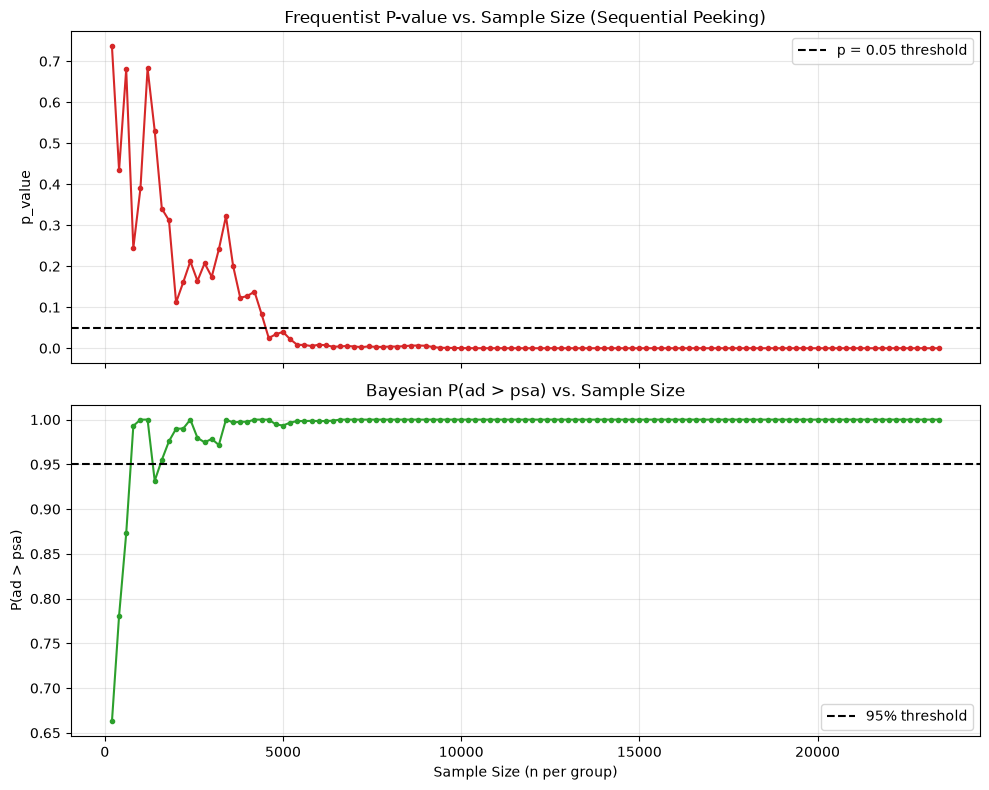

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(results_df['n'], results_df['p_value'], marker='o', markersize=3, color='tab:red')
axes[0].axhline(0.05, color='black', linestyle='--', label='p = 0.05 threshold')
axes[0].set_ylabel('p_value')
axes[0].set_title('Frequentist P-value vs. Sample Size (Sequential Peeking)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(results_df['n'], results_df['prob_ad_better'], marker='o', markersize=3, color='tab:green')
axes[1].axhline(0.95, color='black', linestyle='--', label='95% threshold')
axes[1].set_ylabel('P(ad > psa)')
axes[1].set_xlabel('Sample Size (n per group)')
axes[1].set_title('Bayesian P(ad > psa) vs. Sample Size')
axes[1].legend()
axes[1].grid(alpha=0.3)

import os
os.makedirs('images', exist_ok=True)

plt.tight_layout()
plt.savefig('images/peeking_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

### Sequential Peeking: Results

The p-value fluctuates substantially at small sample sizes, crossing above and below the 0.05 threshold multiple times before stabilizing below it around n≈4,000-5,000 per group. An analyst "peeking" at an earlier checkpoint (e.g., n=1,500, p≈0.68) could easily have concluded there was no effect — a false negative driven by stopping early, not by the absence of a real effect.

The Bayesian P(ad > psa) is also noisy at very small samples, but crosses and stabilizes above the 95% threshold earlier (around n≈1,000-1,500) and does not exhibit the same repeated threshold-crossing behavior seen in the p-value. This makes it more robust to a "check whenever you want" monitoring approach — the core motivation for using Bayesian methods in real-time experimentation.

**Caveat**: this doesn't mean Bayesian posteriors are immune to noise at small samples — they clearly aren't here. The key difference is that the frequentist p-value's validity formally depends on committing to a sample size in advance, while the Bayesian posterior remains interpretable at any point in the data collection process.

## Overall Summary

**Objective**: Compare frequentist and Bayesian approaches to A/B test analysis using a real marketing dataset (588,101 users, `ad` vs `psa` groups).

**Key findings**:
- The `ad` group converted at 2.55% vs. 1.79% for `psa` — a statistically significant difference (z=7.37, p<0.0001) and a Bayesian posterior probability of P(ad > psa) = 1.0000.
- With this much data, frequentist confidence intervals and Bayesian credible intervals were nearly identical, and prior choice had negligible effect on the posterior — the data dominates.
- The sequential peeking simulation showed the real practical difference: the frequentist p-value fluctuated unpredictably at small sample sizes (repeatedly crossing above and below 0.05), while the Bayesian posterior probability stabilized earlier and more smoothly.

**Takeaway**: Frequentist and Bayesian methods largely agree when you have a lot of data and analyze it once. They diverge in practical usefulness when data is being monitored continuously — a common real-world scenario (e.g., checking an experiment's dashboard daily) that frequentist methods aren't formally built to handle without correction (such as sequential testing adjustments), but that Bayesian methods handle more naturally.

**What I'd explore next**: Bayesian regression incorporating covariates like ad frequency and day/hour, and a formal sequential testing correction (e.g., alpha-spending) for a more rigorous frequentist comparison.